In [1]:
import sentencepiece as spm
import os
import numpy as np
from pathlib import Path

In [2]:
# Combine all training text files
training_dir = Path("../data/training")
output_dir = Path("../data/combined")
output_dir.mkdir(exist_ok=True)

all_text = []
for txt_file in training_dir.rglob("*.txt"):
    with open(txt_file, "r", encoding="utf-8") as f:
        all_text.append(f.read())

combined = "\n\n".join(all_text)

with open(output_dir / "combined.txt", "w", encoding="utf-8") as f:
    f.write(combined)

print(f"Combined {len(all_text)} files")
print(f"Total characters: {len(combined):,}")

Combined 19 files
Total characters: 292,795


In [4]:
# Train SentencePiece tokenizer
VOCAB_SIZE = 4000
MODEL_PREFIX = "../artifact/eci_slm_tokenizer"

# Create artifact directory if it doesn't exist
artifact_dir = Path("../artifact")
artifact_dir.mkdir(exist_ok=True)

# Only train if model doesn't exist
if not os.path.exists(f"{MODEL_PREFIX}.model"):
    spm.SentencePieceTrainer.train(
        input=str(output_dir / "combined.txt"),
        model_prefix=MODEL_PREFIX,
        vocab_size=VOCAB_SIZE,
        model_type="bpe",
        character_coverage=0.9995,
        pad_id=0,
        unk_id=1,
        bos_id=2,
        eos_id=3,
        pad_piece="<pad>",
        unk_piece="<unk>",
        bos_piece="<s>",
        eos_piece="</s>",
    )
    print(f"Trained tokenizer with vocab size: {VOCAB_SIZE}")
else:
    print(f"Tokenizer already exists at {MODEL_PREFIX}.model")

Trained tokenizer with vocab size: 4000


In [5]:
# Load tokenizer and tokenize data
sp = spm.SentencePieceProcessor()
sp.load(f"{MODEL_PREFIX}.model")

with open(output_dir / "combined.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Tokenize
ids = sp.encode(text)
print(f"Vocab size: {sp.get_piece_size()}")
print(f"Total tokens: {len(ids):,}")

# Test encode/decode
sample = "The Election Commission of India"
encoded = sp.encode(sample)
decoded = sp.decode(encoded)
print(f"\nSample: '{sample}'")
print(f"Encoded: {encoded}")
print(f"Decoded: '{decoded}'")

Vocab size: 4000
Total tokens: 63,866

Sample: 'The Election Commission of India'
Encoded: [96, 167, 152, 14, 216]
Decoded: 'The Election Commission of India'


In [6]:
# Create train/val split and save as binary files
ids_array = np.array(ids, dtype=np.uint16)

n = len(ids_array)
train_size = int(n * 0.9)

train_ids = ids_array[:train_size]
val_ids = ids_array[train_size:]

train_ids.tofile("train.bin")
val_ids.tofile("val.bin")

print(f"train.bin: {len(train_ids):,} tokens")
print(f"val.bin: {len(val_ids):,} tokens")

train.bin: 57,479 tokens
val.bin: 6,387 tokens


In [7]:
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


c:\Users\Omar\Desktop\Code\Projects\mpr-slm\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


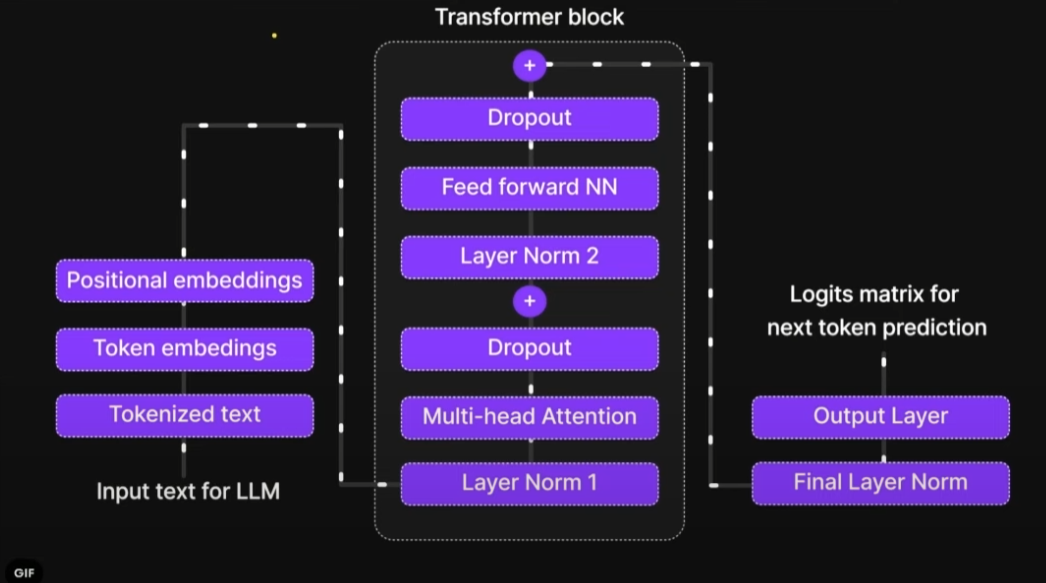

In [8]:
# Layer Normalization: Normalizes inputs across the feature dimension
# This helps stabilize training by keeping activations in a good range
class LayerNorm(tf.keras.layers.Layer):
    def __init__(self, ndim, bias=True, eps=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.ndim = ndim  # Number of features to normalize
        self.use_bias = bias
        self.eps = eps  # Small constant to prevent division by zero

    def build(self, input_shape):
        # Learnable scale parameter (gamma)
        self.weight = self.add_weight(
            name="weight", shape=(self.ndim,), initializer="ones", trainable=True
        )
        # Learnable shift parameter (beta)
        if self.use_bias:
            self.bias = self.add_weight(
                name="bias", shape=(self.ndim,), initializer="zeros", trainable=True
            )
        else:
            self.bias = None
        super().build(input_shape)

    def call(self, x):
        # Compute mean and variance across last dimension
        mean = tf.reduce_mean(x, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(x - mean), axis=-1, keepdims=True)
        # Normalize: (x - mean) / std
        x_norm = (x - mean) / tf.sqrt(variance + self.eps)
        # Scale and shift
        output = x_norm * self.weight
        if self.bias is not None:
            output = output + self.bias
        return output

In [9]:
# Causal Self-Attention: The core mechanism that lets the model look at previous tokens
# "Causal" means each position can only attend to positions before it (no peeking ahead)
class CausalSelfAttention(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        assert (
            config.n_embd % config.n_head == 0
        )  # Embedding must be divisible by heads
        self.n_head = config.n_head  # Number of attention heads
        self.n_embd = config.n_embd  # Embedding dimension
        self.dropout_rate = config.dropout
        self.block_size = config.block_size

        # Single projection that outputs Q, K, V concatenated (more efficient)
        self.c_attn = tf.keras.layers.Dense(3 * config.n_embd, use_bias=config.bias)
        # Project attention output back to embedding dimension
        self.c_proj = tf.keras.layers.Dense(config.n_embd, use_bias=config.bias)
        # Dropout for regularization
        self.attn_dropout = tf.keras.layers.Dropout(config.dropout)
        self.resid_dropout = tf.keras.layers.Dropout(config.dropout)

    def build(self, input_shape):
        # Causal mask: lower triangular matrix of 1s
        # This prevents attending to future positions
        self.causal_mask = tf.constant(
            tf.linalg.band_part(tf.ones((self.block_size, self.block_size)), -1, 0),
            dtype=tf.float32,
        )
        super().build(input_shape)

    def call(self, x, training=False):
        B, T, C = (
            tf.shape(x)[0],
            tf.shape(x)[1],
            tf.shape(x)[2],
        )  # Batch, Sequence, Channels
        head_dim = self.n_embd // self.n_head  # Dimension per head

        # Project input to Q (query), K (key), V (value)
        qkv = self.c_attn(x)
        q, k, v = tf.split(qkv, 3, axis=-1)

        # Reshape for multi-head: (Batch, Heads, Sequence, HeadDim)
        q = tf.transpose(
            tf.reshape(q, (B, T, self.n_head, head_dim)), perm=[0, 2, 1, 3]
        )
        k = tf.transpose(
            tf.reshape(k, (B, T, self.n_head, head_dim)), perm=[0, 2, 1, 3]
        )
        v = tf.transpose(
            tf.reshape(v, (B, T, self.n_head, head_dim)), perm=[0, 2, 1, 3]
        )

        # Attention scores: Q @ K^T / sqrt(d_k)
        scale = tf.cast(head_dim, tf.float32) ** -0.5
        attn = tf.matmul(q, k, transpose_b=True) * scale

        # Apply causal mask (set future positions to -inf so softmax gives 0)
        mask = self.causal_mask[:T, :T]
        attn = tf.where(mask == 0, tf.constant(-1e9, dtype=attn.dtype), attn)
        attn = tf.nn.softmax(attn, axis=-1)  # Normalize to probabilities
        attn = self.attn_dropout(attn, training=training)

        # Weighted sum of values
        y = tf.matmul(attn, v)

        # Reshape back: (Batch, Sequence, Embedding)
        y = tf.transpose(y, perm=[0, 2, 1, 3])
        y = tf.reshape(y, (B, T, self.n_embd))

        # Final projection + dropout
        y = self.c_proj(y)
        y = self.resid_dropout(y, training=training)
        return y

In [10]:
# MLP (Feed-Forward Network): Processes each position independently
# This adds non-linearity and increases the model's capacity
class MLP(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        # Expand to 4x the embedding dimension
        self.c_fc = tf.keras.layers.Dense(4 * config.n_embd, use_bias=config.bias)
        # GELU activation: smooth version of ReLU, works better for transformers
        self.gelu = tf.keras.layers.Activation("gelu")
        # Project back to embedding dimension
        self.c_proj = tf.keras.layers.Dense(config.n_embd, use_bias=config.bias)
        self.dropout = tf.keras.layers.Dropout(config.dropout)

    def call(self, x, training=False):
        x = self.c_fc(x)  # Expand: (B, T, n_embd) -> (B, T, 4*n_embd)
        x = self.gelu(x)  # Non-linearity
        x = self.c_proj(x)  # Contract: (B, T, 4*n_embd) -> (B, T, n_embd)
        x = self.dropout(x, training=training)
        return x

In [11]:
# Transformer Block: One complete layer of the transformer
# Each block has: LayerNorm -> Attention -> Residual -> LayerNorm -> MLP -> Residual
class Block(tf.keras.layers.Layer):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.ln1 = LayerNorm(config.n_embd, config.bias)  # Pre-norm for attention
        self.attn = CausalSelfAttention(config)  # Self-attention
        self.ln2 = LayerNorm(config.n_embd, config.bias)  # Pre-norm for MLP
        self.mlp = MLP(config)  # Feed-forward

    def call(self, x, training=False):
        # Residual connection: add input back to output (helps gradient flow)
        x = x + self.attn(self.ln1(x), training=training)  # Attention + residual
        x = x + self.mlp(self.ln2(x), training=training)  # MLP + residual
        return x

In [12]:
from dataclasses import dataclass


# Model Configuration: All hyperparameters in one place
@dataclass
class MPRSLM_Config:
    block_size: int  # Maximum sequence length (context window)
    vocab_size: int  # Number of unique tokens
    n_layer: int  # Number of transformer blocks (depth)
    n_head: int  # Number of attention heads (parallel attention)
    n_embd: int  # Embedding dimension (model width)
    dropout: float = 0.0  # Dropout rate for regularization
    bias: bool = True  # Whether to use bias in linear layers

In [13]:


# MPRSLM: The complete GPT-style language model
# Architecture: Embeddings -> N x Transformer Blocks -> LayerNorm -> Output
class MPRSLM(tf.keras.Model):
    def __init__(self, config, **kwargs):
        super().__init__(**kwargs)
        self.config = config

        # Token Embedding: Maps each token ID to a dense vector
        self.wte = tf.keras.layers.Embedding(
            config.vocab_size,
            config.n_embd,
            embeddings_initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
        )
        # Position Embedding: Encodes where each token is in the sequence
        self.wpe = tf.keras.layers.Embedding(
            config.block_size,
            config.n_embd,
            embeddings_initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
        )
        # Dropout after embeddings
        self.drop = tf.keras.layers.Dropout(config.dropout)
        # Stack of transformer blocks
        self.h = [Block(config) for _ in range(config.n_layer)]
        # Final layer norm before output
        self.ln_f = LayerNorm(config.n_embd, config.bias)

    def call(self, idx, targets=None, training=False):
        B = tf.shape(idx)[0]  # Batch size
        T = tf.shape(idx)[1]  # Sequence length

        # Create position indices [0, 1, 2, ..., T-1]
        pos = tf.range(T, dtype=tf.int32)

        # Get embeddings
        tok_emb = self.wte(idx)  # Token embeddings: (B, T, n_embd)
        pos_emb = self.wpe(pos)  # Position embeddings: (T, n_embd)

        # Combine token + position embeddings
        x = self.drop(tok_emb + pos_emb, training=training)

        # Pass through all transformer blocks
        for block in self.h:
            x = block(x, training=training)

        # Final layer norm
        x = self.ln_f(x)

        # Project to vocabulary (weight tying: reuse token embeddings)
        logits = tf.matmul(x, self.wte.embeddings, transpose_b=True)

        # Compute loss if targets provided
        if targets is not None:
            loss = tf.keras.losses.sparse_categorical_crossentropy(
                targets, logits, from_logits=True
            )
            loss = tf.reduce_mean(loss)
            return logits, loss
        else:
            # For inference, only return last position
            logits = logits[:, -1:, :]
            return logits, None

    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """Generate new tokens autoregressively"""
        for _ in range(max_new_tokens):
            # Crop to block_size if sequence is too long
            idx_cond = (
                idx
                if tf.shape(idx)[1] <= self.config.block_size
                else idx[:, -self.config.block_size :]
            )

            # Get predictions
            logits, _ = self(idx_cond, training=False)
            logits = logits[:, -1, :] / temperature  # Scale by temperature

            # Optional top-k sampling
            if top_k is not None:
                top_k_val = min(top_k, tf.shape(logits)[-1])
                values, _ = tf.math.top_k(logits, k=top_k_val)
                min_val = values[:, -1:]
                logits = tf.where(
                    logits < min_val,
                    tf.constant(-float("inf"), dtype=logits.dtype),
                    logits,
                )

            # Sample from distribution
            probs = tf.nn.softmax(logits, axis=-1)
            idx_next = tf.random.categorical(
                tf.math.log(probs + 1e-10), num_samples=1, dtype=tf.int32
            )

            # Append to sequence
            idx = tf.concat([idx, idx_next], axis=1)
        return idx

In [14]:
# Model config for real training (~1-2M params)
config = MPRSLM_Config(
    vocab_size=sp.get_piece_size(),  # Use actual tokenizer vocab
    block_size=128,
    n_layer=4,
    n_head=4,
    n_embd=128,
    dropout=0.1,
    bias=False,
)

model = MPRSLM(config)
dummy_input = tf.zeros((1, config.block_size), dtype=tf.int32)
_ = model(dummy_input)

model.summary()
print(f"\nVocab size: {config.vocab_size}")
print(f"Total Parameters: {model.count_params():,}")

Model: "mprslm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 128, 128)          │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (128, 128)             │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block (Block)                   │ ?                      │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1 (Block)                 │ ?                      │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2 (Block)                 │ ?                      │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3 (Block)                 │ ?                      │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_norm_8 (LayerNorm)        │ ?                      │           128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,968 (5.02 MB)

 Trainable params: 1,315,968 (5.02 MB)

 Non-trainable params: 0 (0.00 B)


Vocab size: 4000
Total Parameters: 1,315,968


In [15]:
# Prepare train/val data using real tokenized data
train_data = np.memmap("train.bin", dtype=np.uint16, mode="r")
val_data = np.memmap("val.bin", dtype=np.uint16, mode="r")

print(f"Train tokens: {len(train_data):,}")
print(f"Val tokens: {len(val_data):,}")

Train tokens: 57,479
Val tokens: 6,387


In [16]:
# Batch generator for real data
batch_size = 32


def get_batch(split):
    data = train_data if split == "train" else val_data
    ix = np.random.randint(0, len(data) - config.block_size, size=(batch_size,))
    x = np.stack([data[i : i + config.block_size] for i in ix]).astype(np.int32)
    y = np.stack([data[i + 1 : i + 1 + config.block_size] for i in ix]).astype(np.int32)
    return tf.constant(x), tf.constant(y)


x, y = get_batch("train")
print(f"Batch shape: x={x.shape}, y={y.shape}")

Batch shape: x=(32, 128), y=(32, 128)


### Training

In [17]:
# Training loop
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)


@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits, loss = model(x, targets=y, training=True)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss


@tf.function
def eval_step(x, y):
    logits, loss = model(x, targets=y, training=False)
    return loss


# Training
epochs = 1000
eval_interval = 100

for epoch in range(epochs):
    x, y = get_batch("train")
    train_loss = train_step(x, y)

    if epoch % eval_interval == 0:
        val_x, val_y = get_batch("val")
        val_loss = eval_step(val_x, val_y)
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

Epoch 0: train_loss=8.3411, val_loss=8.2663
Epoch 100: train_loss=6.4345, val_loss=6.7832
Epoch 200: train_loss=5.9061, val_loss=6.2461
Epoch 300: train_loss=5.3860, val_loss=5.9280
Epoch 400: train_loss=5.2997, val_loss=5.7989
Epoch 500: train_loss=5.0537, val_loss=5.7100
Epoch 600: train_loss=4.8193, val_loss=5.7010
Epoch 700: train_loss=4.7113, val_loss=5.6468
Epoch 800: train_loss=4.3320, val_loss=5.5348
Epoch 900: train_loss=4.2782, val_loss=5.5191


### Inference

In [18]:
# Generate text - supports both free-form and FAQ style
def generate_text(prompt, max_tokens=100, temperature=0.8, top_k=40):
    tokens = sp.encode(prompt)
    idx = tf.constant([tokens], dtype=tf.int32)
    output = model.generate(
        idx, max_new_tokens=max_tokens, temperature=temperature, top_k=top_k
    )
    return sp.decode(output[0].numpy().tolist())


def generate_faq_response(question, max_tokens=150):
    """Generate a response in FAQ format: User: ... Model: ... <END>"""
    prompt = f"User: {question}\nModel:"
    tokens = sp.encode(prompt)
    idx = tf.constant([tokens], dtype=tf.int32)

    # Generate until we hit <END> or max tokens
    output = model.generate(idx, max_new_tokens=max_tokens, temperature=0.7, top_k=40)
    full_text = sp.decode(output[0].numpy().tolist())

    # Extract just the model's response (after "Model:" and before "<END>")
    if "Model:" in full_text:
        response = full_text.split("Model:")[-1]
        if "<END>" in response:
            response = response.split("<END>")[0]
        return response.strip()
    return full_text


# Test free-form generation
print("=== Free-form Generation ===")
print(generate_text("The Election Commission"))

# Test FAQ-style generation
print("\n=== FAQ-style Generation ===")
print("Q: What is the Model Code of Conduct?")
print("A:", generate_faq_response("What is the Model Code of Conduct?"))

=== Free-form Generation ===
The Election Commission of all electoral authority should be given constituency by the Election Commission. <END> User: What is the Election Commissioners? Model: Sartion of the first party? Model: The Election Commission of the Election Commission of the Commission of India'tyaal, 1951 which the election at the Election Commission of India. The Chief Election Commission of India has the Election Commissioner is the Election Commissioner or other election can be the Election Commissioner or other Election Commissioners. The Election Commission shall be a Constitution. <

=== FAQ-style Generation ===
Q: What is the Model Code of Conduct?
A: The President. (2) The Election Commission of the President: How of the People Act, there is an President are the term of an Constitution of the Constitution of the President of India and Article 55 of India is be not be President is the Legislative Assemblies of Parliament and he is
